# Analyse des émissions CO2e par voyageur-kilomètre

Dataset : `emission-de-co2e-par-voyageur-kilometre-sur-le-reseau (1).xlsx` (IDFM)

**Schéma réel du fichier** :
- `transportmode` : mode de transport (metro, tram, rail)
- `id_line` : identifiant de la ligne
- `name_line` : nom de la ligne
- `co2e_voy_km` : émissions de CO2e de la ligne (g/voyageur-km)
- `co2e_voy_km_par_mode_de_transport_medias_idfm` : moyenne par mode
- `source` : source de la donnée
- `lien_source` : lien vers la source

In [ ]:
# =============================================================================
# IMPORTS — tous les imports nécessaires sont ici, le notebook est autonome
# =============================================================================
import os
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration de l'affichage
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette("pastel")
pd.set_option('display.max_colwidth', 50)

In [4]:
# =============================================================================
# 1. GESTION DU CHEMIN ET CHARGEMENT
# =============================================================================

# Détection automatique du dossier racine du projet
current_dir = Path(os.getcwd())
# Si on est dans le dossier 'notebooks', on remonte d'un cran pour trouver 'data'
base_path = current_dir.parent if current_dir.name == 'notebooks' else current_dir

# Nom exact du fichier
filename = 'emission-de-co2e-par-voyageur-kilometre-sur-le-reseau (1).xlsx'
file_path = base_path / 'data' / filename

print(f"🔍 Tentative d'accès au fichier : {file_path.absolute()}")

try:
    # Chargement du fichier Excel
    # Note : Nécessite 'openpyxl' (pip install openpyxl)
    df_emissions = pd.read_excel(file_path)
    
    print("✅ Fichier chargé avec succès !")
    print(f"📊 Dimensions : {df_emissions.shape[0]} lignes, {df_emissions.shape[1]} colonnes")
    
    # Affichage des informations essentielles
    print("\n📋 Colonnes détectées :")
    print(df_emissions.columns.tolist())
    
    print("\n💾 Empreinte mémoire :")
    print(f"{df_emissions.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # Aperçu des données
    display(df_emissions.head())

except FileNotFoundError:
    print(f"❌ Erreur : Le fichier '{filename}' est introuvable.")
    print(f"Dossier actuel : {os.getcwd()}")
    # Liste les fichiers dans data pour aider au debug
    data_dir = base_path / 'data'
    if data_dir.exists():
        print(f"Contenu de /data : {[f.name for f in data_dir.iterdir()]}")
    else:
        print("Le dossier /data n'a pas été trouvé au chemin attendu.")
except Exception as e:
    print(f"❌ Une erreur inattendue est survenue : {e}")

🔍 Tentative d'accès au fichier : c:\Users\louni\projetEtudeM2\smart-mobility-paris-m2-project\data\emission-de-co2e-par-voyageur-kilometre-sur-le-reseau (1).xlsx
✅ Fichier chargé avec succès !
📊 Dimensions : 56 lignes, 7 colonnes

📋 Colonnes détectées :
['transportmode', 'id_line', 'name_line', 'co2e_voy_km', 'co2e_voy_km_par_mode_de_transport_medias_idfm', 'source', 'lien_source']

💾 Empreinte mémoire :
0.02 MB


,transportmode,id_line,name_line,co2e_voy_km,co2e_voy_km_par_mode_de_transport_medias_idfm,source,lien_source
0,metro,C01380,10,3.80,3.80,RATP 2019,https://www.ratp.fr/aide-contact/questions/cal...
1,metro,C01371,1,3.80,3.80,RATP 2019,https://www.ratp.fr/aide-contact/questions/cal...
2,tram,C02317,T9,3.40,3.20,NaN,NaN
3,rail,C01728,D,6.60,5.50,Transilien 2019,https://www.transilien.com/fr/page-corporate/c...
4,rail,C01857,TER Centre - Val-de-Loire,26.93,26.93,SNCF 2019,https://www.sncf-connect.com/train/eco-respons...


In [ ]:
# Création d'une copie pour travailler proprement
df_clean = df_emissions.copy()

# 1. Nettoyage des colonnes textuelles
# On traite les espaces et on s'assure que les noms de modes sont uniformes
text_cols = ['transportmodeid', 'linename', 'medias_idfm', 'source']
for col in text_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.strip().str.lower()

# 2. Conversion numérique forcée
# 'co2e_voy_km' : émissions de la ligne spécifique
# 'co2e_voy_km_par_mode_de_transport' : moyenne du mode (métro, tram, etc.)
cols_to_fix = ['co2e_voy_km', 'co2e_voy_km_par_mode_de_transport']

for col in cols_to_fix:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# 3. Gestion des valeurs manquantes
# On supprime les lignes où l'émission est nulle car on ne peut pas les analyser
df_clean.dropna(subset=['co2e_voy_km'], inplace=True)

# 4. Renommage pour plus de clarté (Optionnel mais recommandé)
df_clean.rename(columns={
    'transportmode': 'mode',
    'linename': 'ligne',
    'co2e_voy_km': 'co2e_ligne',
    'co2e_voy_km_par_mode_de_transport': 'co2e_moyen_mode'
}, inplace=True)

print("✅ Nettoyage terminé !")
print(f"📉 Taille finale : {df_clean.shape[0]} lignes.")

# Affichage des statistiques par mode de transport
print("\n🔎 Émissions moyennes par mode de transport (g CO2e/voy.km) :")
stats_mode = df_clean.groupby('mode')['co2e_ligne'].agg(['mean', 'min', 'max', 'count']).sort_values('mean')
display(stats_mode)

print("\n📊 Aperçu du dataset nettoyé :")
display(df_clean.head())

✅ Nettoyage terminé !
📉 Taille finale : 55 lignes.

🔎 Émissions moyennes par mode de transport (g CO2e/voy.km) :


,mean,min,max,count
mode,,,,
tram,3.215385,3.1,3.40,13
metro,3.800000,3.8,3.80,16
rail,14.778077,3.8,26.93,26



📊 Aperçu du dataset nettoyé :


,mode,id_line,name_line,co2e_ligne,co2e_voy_km_par_mode_de_transport_medias_idfm,source,lien_source
0,metro,C01380,10,3.80,3.80,ratp 2019,https://www.ratp.fr/aide-contact/questions/cal...
1,metro,C01371,1,3.80,3.80,ratp 2019,https://www.ratp.fr/aide-contact/questions/cal...
2,tram,C02317,T9,3.40,3.20,nan,NaN
3,rail,C01728,D,6.60,5.50,transilien 2019,https://www.transilien.com/fr/page-corporate/c...
4,rail,C01857,TER Centre - Val-de-Loire,26.93,26.93,sncf 2019,https://www.sncf-connect.com/train/eco-respons...


🏆 Classement des modes de transport (du plus écologique au plus polluant) :
----------------------------------------------------------------------
   - TRAM       :   3.22 g CO2e/voy-km
   - METRO      :   3.80 g CO2e/voy-km
   - RAIL       :  14.78 g CO2e/voy-km
----------------------------------------------------------------------


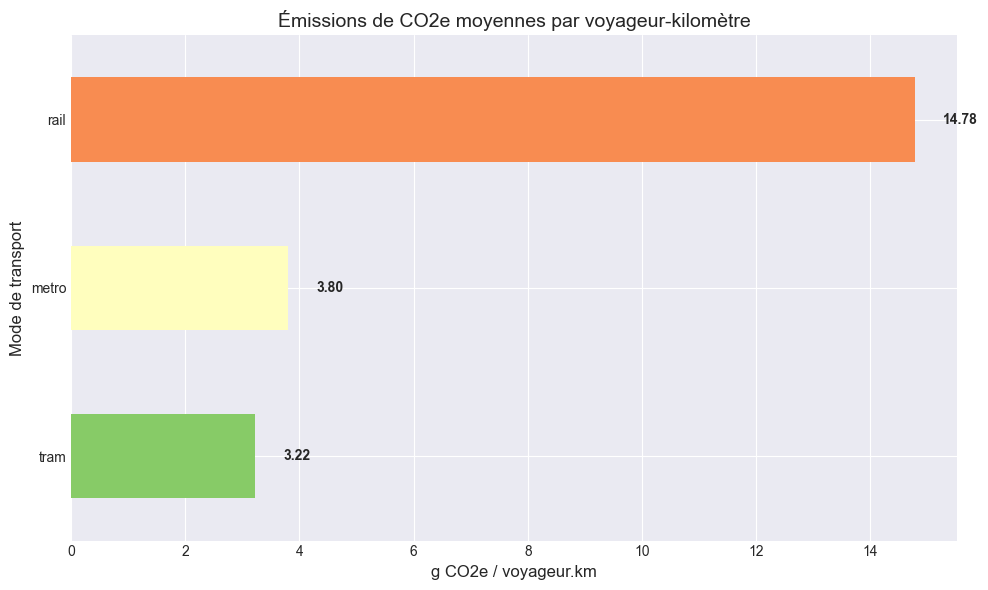

In [15]:
# Utilisation du nom de colonne détecté dans ton aperçu : 'transportmodeid'
mode_column = 'mode' 
value_column = 'co2e_ligne'


if mode_column in df_clean.columns:
    # Agrégation et tri (du plus petit au plus grand rejet de CO2)
    emissions_by_mode = df_clean.groupby(mode_column)[value_column].mean().sort_values(ascending=True)
    
    print(f"🏆 Classement des modes de transport (du plus écologique au plus polluant) :")
    print("-" * 70)
    for mode, value in emissions_by_mode.items():
        # On utilise .upper() pour que les noms de modes (metro, rail...) ressortent mieux
        print(f"   - {mode.upper():<10} : {value:>6.2f} g CO2e/voy-km")
    print("-" * 70)

    # --- Visualisation du classement ---
    plt.figure(figsize=(10, 6))
    colors = sns.color_palette("RdYlGn_r", len(emissions_by_mode)) # Vert pour écolo, rouge pour polluant
    
    emissions_by_mode.plot(kind='barh', color=colors)
    
    plt.title("Émissions de CO2e moyennes par voyageur-kilomètre", fontsize=14)
    plt.xlabel("g CO2e / voyageur.km", fontsize=12)
    plt.ylabel("Mode de transport", fontsize=12)
    
    # Ajout des valeurs au bout des barres
    for i, v in enumerate(emissions_by_mode):
        plt.text(v + 0.5, i, f"{v:.2f}", va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

else:
    print(f"❌ La colonne '{mode_column}' n'existe pas.")
    print(f"Colonnes disponibles : {df_clean.columns.tolist()}")